## Customer Purchase Behaviour  

**PART - A : Fundamentals**

(1). Write a Short note : What is Data Analysis?

Answer :
Data Analysis is the process of collecting, cleaning, organizing, and examining data to find useful information and support decision-making.

(2). Describe how to plan a Data Science Project, Listing all steps.

Answer : There are 6 Phase in it .

1. Problem Defination
2. Data Cleaning 
3. EDA + Feature Engineering
4. Modeling Selection
5. Evalution
6. Deployment + Monitoring

(3). Frame a Machine Learning problem statement: Predict Whether a customer will churn based on purchase behaviour.

Answer : Problem Statement: Predict whether a customer will churn (leave the company) based on purchase behavior, income, age, and other customer details.

(4-A). What are Tensors ?

Answer : A Tensors is mathematical object that generalizes scalers (0D),Vectors (1D),and Matrices (2D) to higher Dimensions.  OR   A Tensor is just A contains for data in multiple dimensions.

(4-B). Provide an in-depth explanation of tensors with simple examples using Numpy.

4. What are Tensors?

Answer:
A tensor is a mathematical structure used to store data in multiple dimensions. It is widely used in Machine Learning and Deep Learning.

Examples:

Scalar (0D): 5

Vector (1D): [1, 2, 3]

Matrix (2D): [[1,2],[3,4]]

Tensor (3D+): Collection of matrices

**PART -  B : Data Acquistion**

In [34]:
import pandas as pd
import numpy as np
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

(5). Import Datasets from different sources :

In [35]:
# 1. Load CSV File using Pandas
df = pd.read_csv("Customer.csv")
print(df.head())

   ID   Name  Age Department  Salary
0   1   Amit   25         IT   45000
1   2  Priya   28         HR   40000
2   3  Rahul   30    Finance   55000
3   4   Neha   26  Marketing   42000
4   5  Karan   35      Sales   60000


In this code i have load the csv file with the help of pandas function.

In [36]:
# 2. Parse a JSON File
json_df = pd.read_json("Customer.json")
print(json_df.head())

   ID   Name  Age Department  Salary
0   1   Amit   25         IT   45000
1   2  Priya   28         HR   40000
2   3  Rahul   30    Finance   55000
3   4   Neha   26  Marketing   42000
4   5  Karan   35      Sales   60000


In this code i have load the csv file with the help of json.

In [37]:
# 3. Connect to SQL Database and Fetch Records
conn = sqlite3.connect("employee.db")
df.to_sql("Customer", conn, if_exists="replace", index=False)

sql_df = pd.read_sql_query("SELECT * FROM Customer", conn)

print(sql_df.head())

conn.close()
conn.close()

   ID   Name  Age Department  Salary
0   1   Amit   25         IT   45000
1   2  Priya   28         HR   40000
2   3  Rahul   30    Finance   55000
3   4   Neha   26  Marketing   42000
4   5  Karan   35      Sales   60000


In this code i have load the csv file with the help of SQL.

In [38]:
# 4. Fetch Data from an API
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)
api_df = pd.DataFrame(response.json())
print(api_df.head())

   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romaguera-Crona', 'catchPhrase': 'Mu

In this code i have Fetch Data from an API.

**PART - C : Data Understanding & Cleaning**

(6). Perform intial exploration :
(7). Apply Data Handling :

In [39]:
print(df.head())

   ID   Name  Age Department  Salary
0   1   Amit   25         IT   45000
1   2  Priya   28         HR   40000
2   3  Rahul   30    Finance   55000
3   4   Neha   26  Marketing   42000
4   5  Karan   35      Sales   60000


In this code I used a Head function for taking first five rows from database.

In [40]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          20 non-null     int64
 1   Name        20 non-null     str  
 2   Age         20 non-null     int64
 3   Department  20 non-null     str  
 4   Salary      20 non-null     int64
dtypes: int64(3), str(2)
memory usage: 932.0 bytes
None


In this code I have taken the information of database. (using a info function).

In [41]:
print(df.describe())

             ID        Age        Salary
count  20.00000  20.000000     20.000000
mean   10.50000  29.350000  50100.000000
std     5.91608   3.498496   7893.368302
min     1.00000  24.000000  39000.000000
25%     5.75000  26.750000  44500.000000
50%    10.50000  29.000000  48500.000000
75%    15.25000  32.000000  55500.000000
max    20.00000  36.000000  65000.000000


In this code I have describe the count, mean , std , min , and so on of Numerical Values(using describe function).

In [42]:
# Missing Values
print(df.isnull().sum())

ID            0
Name          0
Age           0
Department    0
Salary        0
dtype: int64


In this code I have Shown if there is null value or not in database(using isnull function).

In [43]:
# Fill Missing Value
df.fillna(0, inplace=True)

,ID,Name,Age,Department,Salary
0,1,Amit,25,IT,45000
1,2,Priya,28,HR,40000
2,3,Rahul,30,Finance,55000
3,4,Neha,26,Marketing,42000
4,5,Karan,35,Sales,60000
5,6,Anjali,29,IT,48000
6,7,Rohit,32,Finance,57000
7,8,Pooja,27,HR,41000
8,9,Vikram,31,Sales,62000
9,10,Meera,24,Marketing,39000


In this code i have fill the missing value if there is any in database(using fillna function). 

In [44]:
# Check Dupliacte Records
print("Duplicate Rows : " ,df.duplicated().sum())

Duplicate Rows :  0


In this code I have find the Duplicated rows if there is any.

In [45]:
# Remove Duplicate
df.drop_duplicates(inplace=True)

In this code I have Remove the Duplicated rows if there is any.

In [46]:
# Data types
print(df.dtypes)

ID            int64
Name            str
Age           int64
Department      str
Salary        int64
dtype: object


Finding the data types of database.

**PART - D : Exploratory Data Analysis :**
        

(8). Distribution plots of Age,Income,Purchase:

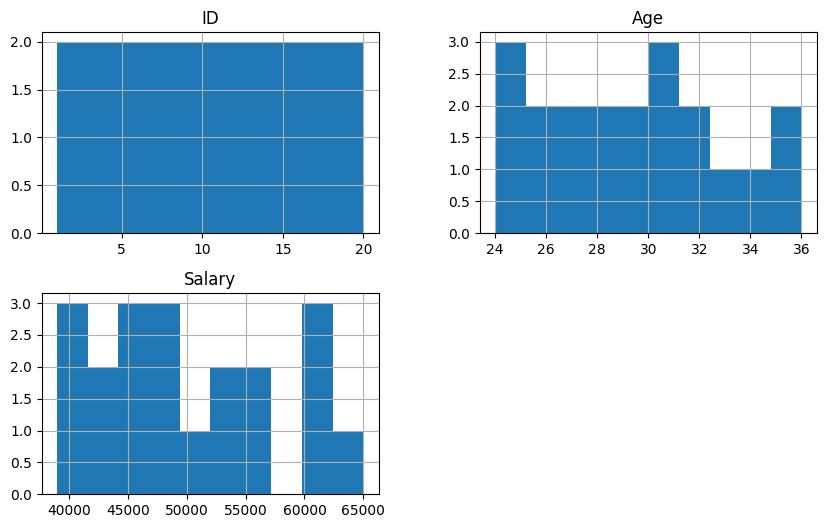

In [47]:
# Histogram
sql_df.hist(figsize=(10,6))
plt.show()

In this code I have Plot a histogram of all The Numerical Values(using hist function). 

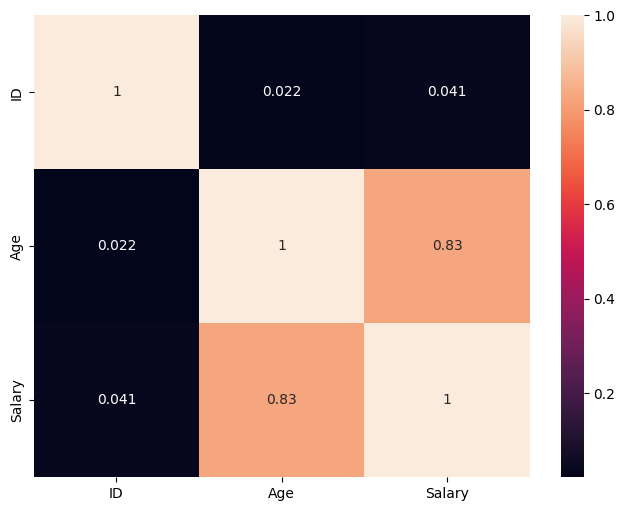

In [48]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
sql_df.corr(numeric_only=True),annot=True)

plt.show()

In this code I have Plot a heatmap of all The Numerical Values(using heatmap function). 

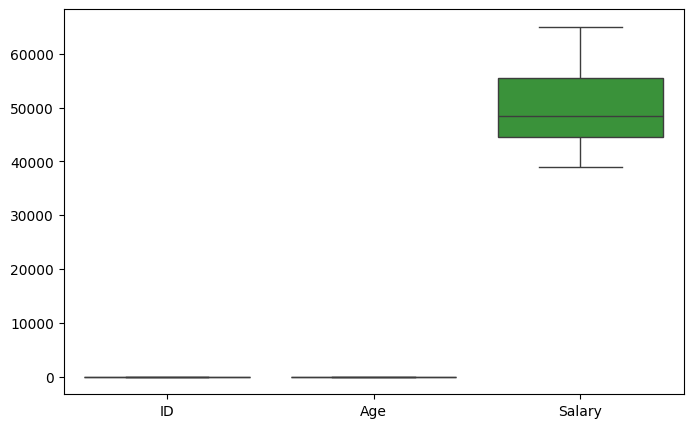

In [49]:
# BoxPlot
plt.figure(figsize=(8,5))
sns.boxplot(data=sql_df)
plt.show()


In this code I have Plot a boxPlot of all The Numerical Values(using boxplot function). 

(9). Perform Bivariate Analysis.

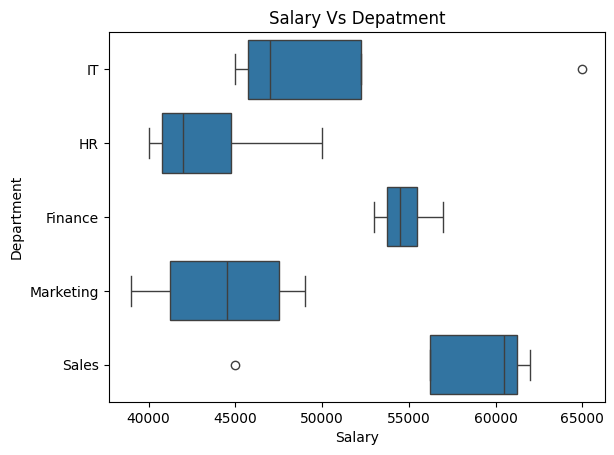

In [50]:
# Name vs Salary
sns.boxplot(x ='Salary',y= 'Department',data=df)
plt.title("Salary Vs Depatment")
plt.show()

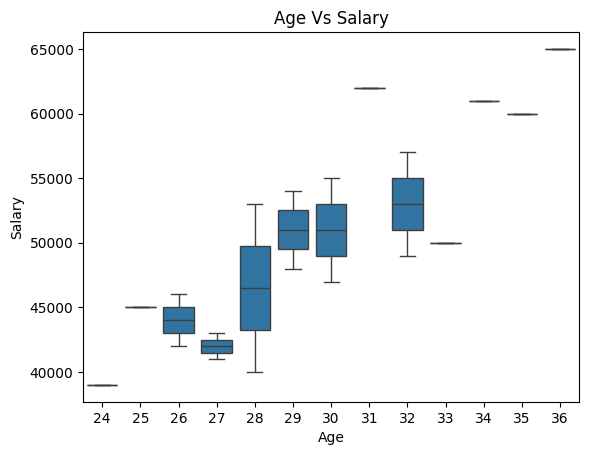

In [51]:
# Name vs Salary
sns.boxplot(x ='Age',y= 'Salary',data=df)
plt.title("Age Vs Salary")
plt.show()

In this both code I perform Bivariate Analysis of Salary Vs Depatment and Age Vs Salary By ploting box plot for them.

(10). Perform Multivariate Analysis :

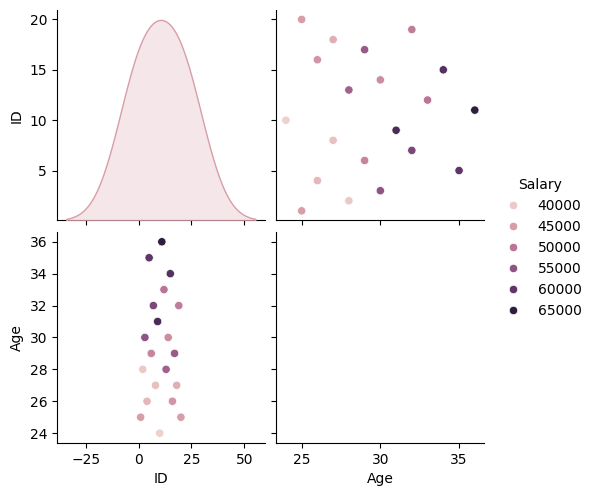

In [52]:

sns.pairplot(df,hue= 'Salary')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

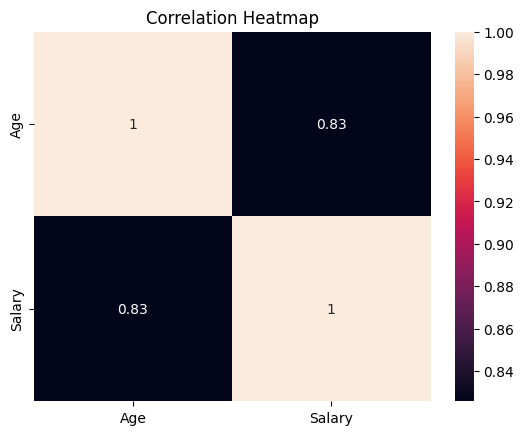

In [53]:
corr = df[['Age','Salary']].corr()
sns.heatmap(corr ,annot=True)
plt.title("Correlation Heatmap")
plt.show


In this both code I perform Multivariate Analysis of Salary i plot Pairplot and I used Correlation Heatmap for Age Vs Salary.

**PART-E : Data Profiling**

(11). Generate a Pandas Profiling Report that summarizes.

Summarize dataset:  38%|███▊      | 8/21 [00:00<00:00, 105.75it/s, scatter ID, ID]            


ModuleNotFoundError: No module named 'matplotlib.backends.backend_svg'

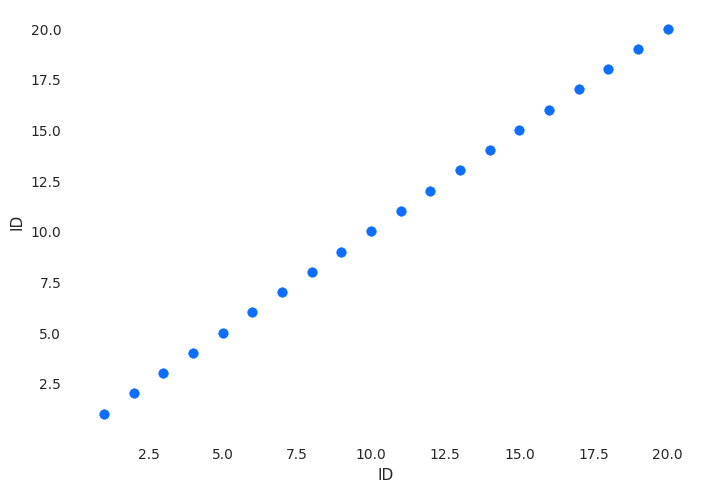

In [61]:
import os
profile =  ProfileReport(df,title = "Employee Data Profiling Report",explorative= True)
profile.to_file("Employee_Report.html")


IN this code i create profile and save report.